# Multi-Site Portfolio Energy Yield Assessment

<span style="font-size:1.2em; color:#003591">
5 US West Coast sites · Solcast TMY weather · parallel fetching & simulation · per-site performance metrics.<br>
Load a CSV, fetch weather in parallel, instantiate a <code>PVSystem</code> per row, simulate — all in one notebook.
</span>

---

> **Caching:** TMY files written to `weather/` on first run — subsequent runs skip the Solcast fetch.


In [1]:
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import solarfarmer as sf
from solarfarmer import PVSystem

# --- DNV plot style ---
DNV = {'navy': '#0f204b', 'blue': '#003591', 'sky': '#009fda',
       'light': '#99d9f0', 'green': '#3f9c35'}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f7fbfe',
    'axes.edgecolor': DNV['navy'],
    'axes.labelcolor': DNV['navy'],
    'axes.titleweight': 'bold',
    'axes.titlecolor': DNV['blue'],
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': DNV['sky'],
    'xtick.color': DNV['navy'],
    'ytick.color': DNV['navy'],
    'font.family': 'Ubuntu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
})

sf.configure_logging()

# ---------------------------------------------------------------------------
# API keys — set as environment variables or paste here for quick testing
# ---------------------------------------------------------------------------
SF_API_KEY      = os.environ.get("SF_API_KEY",      "YOUR_SF_KEY_HERE")
SOLCAST_API_KEY = os.environ.get("SOLCAST_API_KEY", "YOUR_SOLCAST_KEY_HERE")

for name, key in [("SF_API_KEY", SF_API_KEY), ("SOLCAST_API_KEY", SOLCAST_API_KEY)]:
    status = "found" if "YOUR" not in key else "NOT SET — paste it above or export the env var"
    print(f"{name}: {status}")

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
HERE         = Path(".")
WEATHER_DIR  = HERE / "weather"
WEATHER_DIR.mkdir(exist_ok=True)

# Equipment files — the PAN/OND from the WebinarJune2026 equipment folder
PAN_FILE = Path("../WebinarJune2026/equipment/TrinaSolar_TSM-375DE14A(II)_APP.PAN")
OND_FILE = Path("../WebinarJune2026/equipment/60_10_APP02.OND")

print(f"\nPAN file exists: {PAN_FILE.exists()}")
print(f"OND file exists: {OND_FILE.exists()}")


SF_API_KEY: found
SOLCAST_API_KEY: found

PAN file exists: True
OND file exists: True


## Site Portfolio — Load from CSV with the projects' data

The file `sites.csv` defines five plants across the US West Coast with a mix of
tracker and fixed-tilt configurations, and different AC / DC / grid capacities.

In [2]:
sites = pd.read_csv(HERE / "sites.csv")

# Pretty-print key columns
display_cols = [
    "site_id", "site_name", "latitude", "longitude", "altitude",
    "mounting", "tilt", "gcr",
    "dc_capacity_MW", "ac_capacity_MW", "grid_limit_MW",
    "bifacial", "inverter_type",
]
print(f"Portfolio: {len(sites)} sites\n")
sites[display_cols].style.set_caption("Site Portfolio")


Portfolio: 5 sites



,site_id,site_name,latitude,longitude,altitude,mounting,tilt,gcr,dc_capacity_MW,ac_capacity_MW,grid_limit_MW,bifacial,inverter_type
0,CA-01,Los Angeles Solar,34.050000,-118.250000,71,Fixed,20.000000,0.400000,12.000000,10.000000,10.500000,True,Central
1,CA-02,San Diego Solar,32.720000,-117.150000,20,Tracker,35.000000,0.350000,20.000000,17.000000,18.000000,True,String
2,CA-03,Sacramento Solar,38.580000,-121.490000,7,Tracker,40.000000,0.420000,15.000000,12.500000,13.000000,True,Central
3,OR-01,Portland Solar,45.520000,-122.680000,15,Fixed,30.000000,0.450000,8.000000,6.500000,7.000000,False,String
4,WA-01,Seattle Solar,47.610000,-122.330000,56,Fixed,35.000000,0.450000,5.000000,4.000000,4.500000,False,String


## Fetch Solcast TMY Weather Data (Multithreaded)

One TMY request per site, issued **in parallel**.
Results are cached to `weather/<site_id>_tmy.csv` — subsequent runs skip the API call.

> Each Solcast TMY call costs 1 free-tier API credit.

In [3]:
%%time
from solcast import tmy

SOLCAST_PARAMS = [
    "ghi", "dhi", "air_temp", "wind_speed_10m",
    "precipitable_water", "precipitation_rate",
]

# Map site_id → weather TSV path (SolarFarmer-ready)
tmy_tsv: dict[str, Path] = {}


def fetch_tmy_for_site(row: pd.Series) -> tuple[str, Path]:
    """Fetch (or load cached) Solcast TMY and write SolarFarmer TSV. Returns (site_id, tsv_path)."""
    site_id  = row["site_id"]
    csv_path = WEATHER_DIR / f"{site_id}_tmy.csv"
    tsv_path = WEATHER_DIR / f"{site_id}_tmy.tsv"

    # --- Fetch or load ---
    if not csv_path.exists():
        df = tmy.radiation_and_weather(
            latitude=row["latitude"],
            longitude=row["longitude"],
            output_parameters=SOLCAST_PARAMS,
            ghi_weight=1.0, # give GHI full weight (commonly known as "typical GHI year" or TGY)
            dni_weight=0.0,
            api_key=SOLCAST_API_KEY,
        ).to_pandas()
        df.to_csv(csv_path)
        print(f"  {site_id}: fetched {len(df)} records → {csv_path.name}")
    else:
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        print(f"  {site_id}: loaded from cache ({len(df)} records)")

    # --- Convert to SolarFarmer TSV ---
    sf.from_solcast(df=df, output_path=tsv_path)
    return site_id, tsv_path


print("Fetching / loading TMY weather for all sites...")
with ThreadPoolExecutor(max_workers=5) as pool:
    futures = {pool.submit(fetch_tmy_for_site, row): row["site_id"]
               for _, row in sites.iterrows()}
    for future in as_completed(futures):
        sid, path = future.result()
        tmy_tsv[sid] = path

print(f"\nAll {len(tmy_tsv)} TMY files ready in {WEATHER_DIR}/")


Fetching / loading TMY weather for all sites...
  CA-02: loaded from cache (8760 records)
  CA-03: loaded from cache (8760 records)
  OR-01: loaded from cache (8760 records)
  CA-01: loaded from cache (8760 records)
  WA-01: loaded from cache (8760 records)

All 5 TMY files ready in weather/
CPU times: total: 391 ms
Wall time: 332 ms


## Build PVSystem Objects from DataFrame

Instantiate one `PVSystem` per CSV row following **SolarFarmer SDK Workflow 2**. The same PAN / OND equipment files apply to all sites — yield differences are location- and design-driven.


In [4]:
def build_pvsystem(row: pd.Series) -> PVSystem:
    """Instantiate and configure a PVSystem from a DataFrame row (Workflow 2)."""
    site_id = row["site_id"]

    plant = PVSystem(
        name=row["site_name"],
        latitude=float(row["latitude"]),
        longitude=float(row["longitude"]),
        altitude=float(row["altitude"]),
        timezone=row["timezone"],
    )

    # --- Capacity ---
    plant.dc_capacity_MW = float(row["dc_capacity_MW"])
    plant.ac_capacity_MW = float(row["ac_capacity_MW"])
    plant.grid_limit_MW  = float(row["grid_limit_MW"])

    # --- Mounting & orientation ---
    mounting_str = str(row["mounting"]).strip().upper()
    plant.mounting = (
        sf.MountingType.TRACKER
        if mounting_str == "TRACKER"
        else sf.MountingType.FIXED
    )
    plant.tilt    = float(row["tilt"])
    plant.azimuth = float(row["azimuth"])
    plant.gcr     = float(row["gcr"])

    # --- Module / electrical ---
    plant.bifacial = str(row["bifacial"]).strip().upper() == "TRUE"

    inverter_str = str(row["inverter_type"]).strip().upper()
    plant.inverter_type = (
        sf.InverterType.STRING
        if inverter_str == "STRING"
        else sf.InverterType.CENTRAL
    )
    plant.transformer_stages = 1

    # --- Equipment ---
    plant.add_pan_files({"Module": PAN_FILE})
    plant.add_ond_files({"Inverter": OND_FILE})

    # --- Weather ---
    plant.weather_file = tmy_tsv[site_id]

    # Suppress per-plant design summary in output
    plant.print_design_summary = False

    return plant


# Build all systems (fast — no API calls here)
pvsystems: dict[str, PVSystem] = {}
for _, row in sites.iterrows():
    pvsystems[row["site_id"]] = build_pvsystem(row)
    print(f"  {row['site_id']:6s}  {row['site_name']:<24s}  "
          f"{row['dc_capacity_MW']:.1f} MWdc / {row['ac_capacity_MW']:.1f} MWac  "
          f"mounting={row['mounting']}")

print(f"\n{len(pvsystems)} PVSystem objects ready.")


  CA-01   Los Angeles Solar         12.0 MWdc / 10.0 MWac  mounting=Fixed
  CA-02   San Diego Solar           20.0 MWdc / 17.0 MWac  mounting=Tracker
  CA-03   Sacramento Solar          15.0 MWdc / 12.5 MWac  mounting=Tracker
  OR-01   Portland Solar            8.0 MWdc / 6.5 MWac  mounting=Fixed
  WA-01   Seattle Solar             5.0 MWdc / 4.0 MWac  mounting=Fixed

5 PVSystem objects ready.


## Run Energy Calculations (Multithreaded)

Five SolarFarmer API calls dispatched **in parallel** — one per site, each running the full 2D energy simulation against its TMY weather file.


In [5]:
%%time
SF_MAX_WORKERS = 5   # one worker per site — adjust if rate-limited

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def run_site(site_id: str, plant: PVSystem) -> dict:
    """Run SolarFarmer energy calculation for one site and collect key metrics."""
    site_name = plant.name
    variant = plant.make_copy()
    variant.name = site_name  # ensure name is set for results labeling
    variant.run_energy_calculation(
        project_id=f"webinar-{site_id.lower()}",
        api_key=SF_API_KEY,
        print_summary=False,
        save_outputs=False,
    )

    perf = variant.results.get_performance(project_year=1)

    # Monthly net energy
    monthly_raw = variant.results.get_monthly_results_table(
        include_energy_results=True, include_effects=False
    )
    monthly_df  = pd.DataFrame(monthly_raw["energy_results"])
    monthly_y1  = monthly_df[monthly_df["project_year"] == 1].sort_values("month")
    monthly_kwh = {
        f"month_{int(m):02d}": e
        for m, e in zip(monthly_y1["month"], monthly_y1["net_energy"])
    }

    row = {
        "site_id":          site_id,
        "site_name":        variant.name,
        "net_energy_MWh":   perf["net_energy"],
        "energy_yield_kWh_per_kWp": perf["energy_yield"],
        "performance_ratio": perf["performance_ratio"],
        "ghi_kWh_m2":       perf["horizontal_irradiation"],
        "dc_capacity_MW":   variant.dc_capacity_MW,
        "ac_capacity_MW":   variant.ac_capacity_MW,
        **monthly_kwh,
    }
    return row


print(f"Running {len(pvsystems)} SolarFarmer calculations with {SF_MAX_WORKERS} workers...")

all_results: list[dict] = []
with ThreadPoolExecutor(max_workers=SF_MAX_WORKERS) as pool:
    futures = {
        pool.submit(run_site, sid, plant): sid
        for sid, plant in pvsystems.items()
    }
    for future in as_completed(futures):
        row = future.result()
        all_results.append(row)
        print(f"{row['site_id']:6s}  {row['site_name']:<24s}  "
              f"{row['net_energy_MWh']:.1f} MWh  |  "
              f"{row['energy_yield_kWh_per_kWp']:.0f} kWh/kWp  |  "
              f"PR={row['performance_ratio']:.3f}")

# Sort by site_id to match the CSV order
all_results.sort(key=lambda r: r["site_id"])
results_df = pd.DataFrame(all_results)

print(f"\nAll {len(results_df)} calculations complete.")


INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 01-06-2026 11:42:12
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 01-06-2026 11:42:12
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 01-06-2026 11:42:12
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 01-06-2026 11:42:12
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 01-06-2026 11:42:12


Running 5 SolarFarmer calculations with 5 workers...


INFO: SUCCESS: Calculation returned successfully (time taken: 3.6 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 3.8 seconds)


OR-01   Portland Solar            10341.2 MWh  |  1293 kWh/kWp  |  PR=0.802
CA-02   San Diego Solar           42404.2 MWh  |  2121 kWh/kWp  |  PR=0.841


INFO: SUCCESS: Calculation returned successfully (time taken: 8.0 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 8.1 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 8.3 seconds)


WA-01   Seattle Solar             6067.8 MWh  |  1215 kWh/kWp  |  PR=0.776
CA-01   Los Angeles Solar         21638.0 MWh  |  1803 kWh/kWp  |  PR=0.802
CA-03   Sacramento Solar          30265.1 MWh  |  2018 kWh/kWp  |  PR=0.795

All 5 calculations complete.
CPU times: total: 1.06 s
Wall time: 8.42 s


## Performance Metrics — Summary Table

In [6]:
summary_cols = [
    "site_id", "site_name",
    "dc_capacity_MW", "ac_capacity_MW",
    "ghi_kWh_m2", "net_energy_MWh",
    "energy_yield_kWh_per_kWp", "performance_ratio",
]
summary = results_df[summary_cols].copy()

# Merge mounting type from the sites CSV for context
summary = summary.merge(
    sites[["site_id", "mounting"]].rename(columns={"mounting": "Mounting"}),
    on="site_id",
)

summary = summary.rename(columns={
    "site_id":                   "Site ID",
    "site_name":                 "Site Name",
    "dc_capacity_MW":            "DC (MW)",
    "ac_capacity_MW":            "AC (MW)",
    "ghi_kWh_m2":                "GHI (kWh/m²)",
    "net_energy_MWh":            "Net Energy (MWh)",
    "energy_yield_kWh_per_kWp":  "Yield (kWh/kWp)",
    "performance_ratio":         "PR",
})

summary.style \
    .format({
        "DC (MW)": "{:.1f}",
        "AC (MW)": "{:.1f}",
        "GHI (kWh/m²)": "{:.0f}",
        "Net Energy (MWh)": "{:,.0f}",
        "Yield (kWh/kWp)": "{:.0f}",
        "PR": "{:.3f}",
    }) \
    .background_gradient(subset=["Net Energy (MWh)", "Yield (kWh/kWp)", "PR"], cmap="YlGn") \
    .set_caption("Portfolio Performance Summary — Solcast TMY")


,Site ID,Site Name,DC (MW),AC (MW),GHI (kWh/m²),Net Energy (MWh),Yield (kWh/kWp),PR,Mounting
0,CA-01,Los Angeles Solar,12.0,10.0,1990,"21,638",1803,0.802,Fixed
1,CA-02,San Diego Solar,20.0,17.0,1965,"42,404",2121,0.841,Tracker
2,CA-03,Sacramento Solar,15.0,12.5,1914,"30,265",2018,0.795,Tracker
3,OR-01,Portland Solar,8.0,6.5,1398,"10,341",1293,0.802,Fixed
4,WA-01,Seattle Solar,5.0,4.0,1325,"6,068",1215,0.776,Fixed


## Visualise Performance Metrics

Three bar charts side-by-side: **annual net energy**, **specific yield**, and
**performance ratio**, coloured by mounting type.

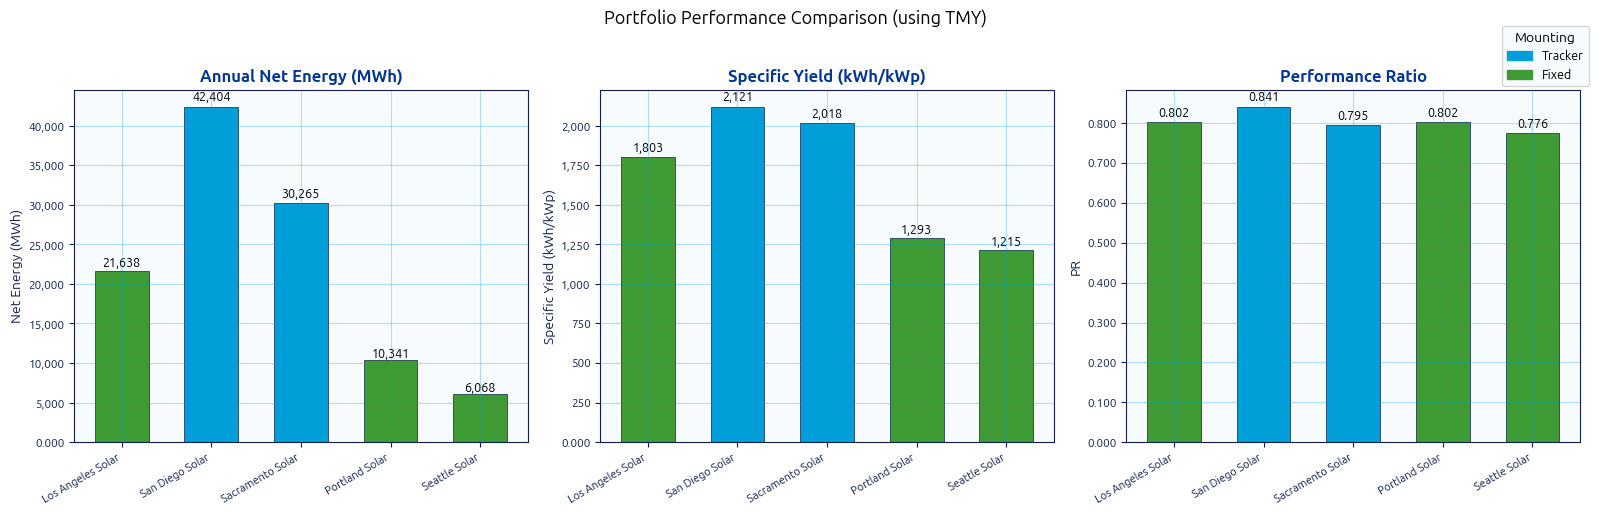

In [7]:
MOUNTING_COLORS = {"Tracker": DNV['sky'], "Fixed": DNV['green']}

labels    = results_df["site_name"].tolist()
site_ids  = results_df["site_id"].tolist()
mountings = sites.set_index("site_id").loc[site_ids, "mounting"].tolist()
colors    = [MOUNTING_COLORS.get(m, DNV['navy']) for m in mountings]

metrics = [
    ("net_energy_MWh",           "Annual Net Energy (MWh)",  "Net Energy (MWh)"),
    ("energy_yield_kWh_per_kWp", "Specific Yield (kWh/kWp)", "Specific Yield (kWh/kWp)"),
    ("performance_ratio",        "Performance Ratio",         "PR"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title, ylabel) in zip(axes, metrics):
    values = results_df[col].tolist()
    bars   = ax.bar(labels, values, color=colors, width=0.6,
                    edgecolor=DNV['navy'], linewidth=0.5)

    for bar, val in zip(bars, values):
        fmt = f"{val:,.0f}" if val > 10 else f"{val:.3f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            fmt, ha="center", va="bottom", fontsize=9,
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}" if x >= 10 else f"{x:.3f}")
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=c, label=m)
    for m, c in MOUNTING_COLORS.items()
]
fig.legend(handles=legend_handles, title="Mounting", loc="upper right",
           bbox_to_anchor=(1.0, 1.0), fontsize=9)

fig.suptitle("Portfolio Performance Comparison (using TMY)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Monthly Energy Profile

Monthly net energy per site — useful to spot seasonal patterns across climates.

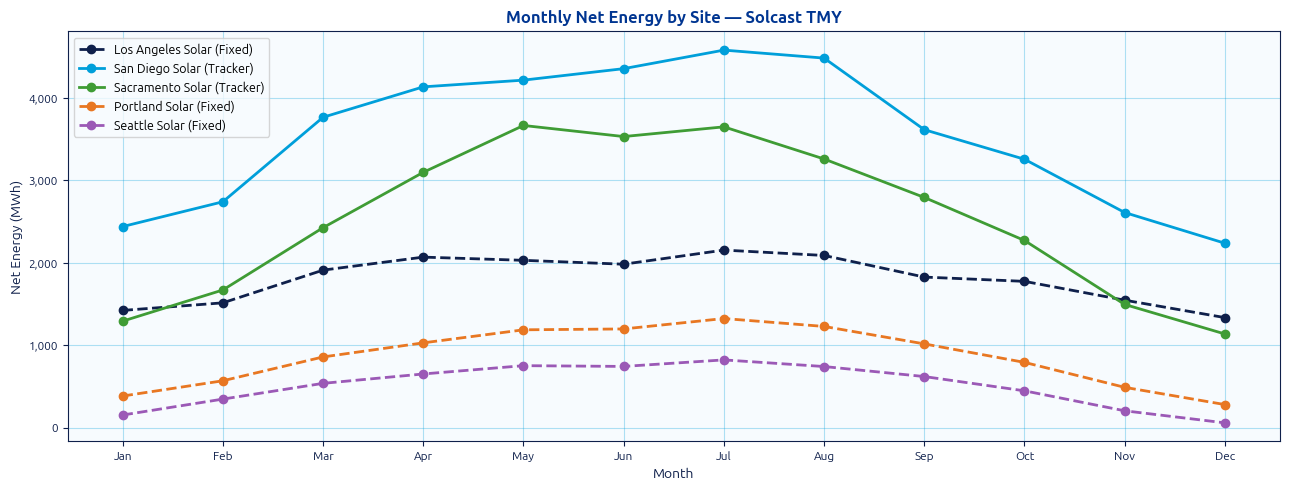

In [8]:
month_cols = [f"month_{m:02d}" for m in range(1, 13)]

# One distinct colour per site, solid = Tracker, dashed = Fixed
SITE_COLORS = ['#0f204b', '#009fda', '#3f9c35', '#e87722', '#9b59b6']

fig, ax = plt.subplots(figsize=(13, 5))

for i, (_, row) in enumerate(results_df.iterrows()):
    monthly_vals = [row[c] for c in month_cols]
    m_type    = sites.loc[sites["site_id"] == row["site_id"], "mounting"].values[0]
    linestyle = "-" if m_type == "Tracker" else "--"
    ax.plot(
        MONTH_LABELS, monthly_vals,
        marker="o", linewidth=2, linestyle=linestyle,
        color=SITE_COLORS[i % len(SITE_COLORS)],
        label=f"{row['site_name']} ({m_type})",
    )

ax.set_title("Monthly Net Energy by Site — Solcast TMY")
ax.set_ylabel("Net Energy (MWh)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


## Normalised Yield — kWh per Installed MW

Raw MWh alongside **specific yield** (kWh/kWp DC) — a size-independent comparison across the portfolio.


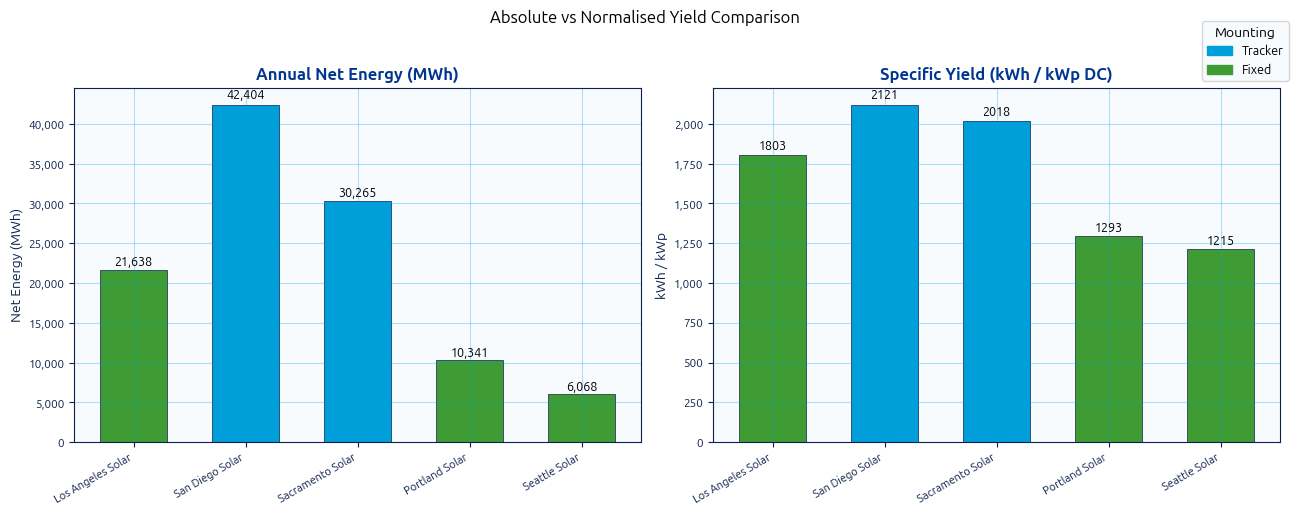

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Gross energy (total MWh) ---
ax = axes[0]
vals = results_df["net_energy_MWh"].tolist()
bars = ax.bar(labels, vals, color=colors, width=0.6,
              edgecolor=DNV['navy'], linewidth=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Annual Net Energy (MWh)")
ax.set_ylabel("Net Energy (MWh)")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# --- Right: Specific yield (kWh/kWp) ---
ax = axes[1]
vals = results_df["energy_yield_kWh_per_kWp"].tolist()
bars = ax.bar(labels, vals, color=colors, width=0.6,
              edgecolor=DNV['navy'], linewidth=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Specific Yield (kWh / kWp DC)")
ax.set_ylabel("kWh / kWp")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=c, label=m)
    for m, c in MOUNTING_COLORS.items()
]
fig.legend(handles=legend_handles, title="Mounting", loc="upper right",
           bbox_to_anchor=(1.0, 1.01), fontsize=9)

fig.suptitle("Absolute vs Normalised Yield Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## Summary

Multi-site energy yield assessment combining Solcast TMY with SolarFarmer Workflow 2 bankable energy calculations.

**Key takeaways:**
- **Tracker vs fixed-tilt** — single-axis trackers produce higher specific yield (kWh/kWp); the gain varies by latitude and seasonal irradiance.
- **Climate gradient** — California sites outperform Pacific Northwest on annual GHI; the gap widens in winter when Seattle and Portland are cloud-dominated.
- **Normalised yield** — specific yield (kWh/kWp) and PR are design-quality metrics independent of installed capacity.
- **Parallel API calls** — `ThreadPoolExecutor` reduces total wall-clock time from O(N × t) to roughly O(t) with minimal code complexity.

**Next steps:**
- Extend to historic / P50–P90 weather for inter-annual variability (see `PVPMC2026/05_solcast_solarfarmer_multiyear.ipynb`)
- Apply soiling losses from Solcast precipitation data via `pvlib.soiling.kimber()`
- Add degradation and OPEX assumptions to build a full LCOE model

---
<div style="text-align:center; color:#003591; font-size:1.1em; margin-top:1em;">
<strong>SolarFarmer Python SDK</strong><br>
<a href="https://dnv-opensource.github.io/solarfarmer-python-sdk/">dnv-opensource.github.io/solarfarmer-python-sdk</a><br>
